# Oriented Object Detection in Aerial Imagery (YOLO OBB)

## Objective
Build a robust object detection pipeline for aerial images with a focus on small object detection.

## Key challenges
- Small object detection (vehicles)
- High-resolution images
- Oriented bounding boxes (OBB)

## Approach
1. Baseline training
2. Problem analysis
3. Tiling strategy
4. Improved training

# Part 1 — Baseline Training with YOLO OBB

## Environment setup

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 89.8 MB/s eta 0:00:00


In [ ]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.26


##Dataset Preparation Check

## Dataset Preparation

The original dataset follows the DOTA annotation format, which uses oriented bounding boxes defined by 4 points.

To make the dataset compatible with YOLO OBB, we perform a structured preprocessing pipeline:

### Steps

* Extract the dataset from compressed format
* Reorganize images and labels into YOLO directory structure
* Convert annotations from DOTA format to YOLO OBB format
* Normalize coordinates to the [0, 1] range

### Output format

Each label is converted into the following structure:

[class_id x1 y1 x2 y2 x3 y3 x4 y4]

Where:

* (x1, y1) … (x4, y4) represent the four corners of the oriented bounding box
* Coordinates are normalized relative to image dimensions

This step ensures full compatibility with Ultralytics YOLO OBB training pipeline.


In [5]:
import zipfile, os

ZIP_PATH = "/content/processed.zip"
EXTRACT_PATH = "/content/data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset ready")

Dataset ready


In [6]:
DATA_ROOT = "/content/data/processed/split"

print("Root:", os.listdir(DATA_ROOT))
print("Train:", os.listdir(os.path.join(DATA_ROOT, "train")))
print("Val:", os.listdir(os.path.join(DATA_ROOT, "val")))

Root: ['train', 'val']
Train: ['images', 'labelTxt']
Val: ['images', 'labelTxt']


In [7]:
import os
import shutil

SRC_ROOT = "/content/data/processed/split"
DST_ROOT = "/content/data/yolo_obb_raw"

for sub in [
    "images/train", "images/val",
    "labels/train", "labels/val"
]:
    os.makedirs(os.path.join(DST_ROOT, sub), exist_ok=True)

# Copier les images
for f in os.listdir(os.path.join(SRC_ROOT, "train", "images")):
    shutil.copy(
        os.path.join(SRC_ROOT, "train", "images", f),
        os.path.join(DST_ROOT, "images", "train", f)
    )

for f in os.listdir(os.path.join(SRC_ROOT, "val", "images")):
    shutil.copy(
        os.path.join(SRC_ROOT, "val", "images", f),
        os.path.join(DST_ROOT, "images", "val", f)
    )

# Copier les labels DOTA txt vers labels/train et labels/val
for f in os.listdir(os.path.join(SRC_ROOT, "train", "labelTxt")):
    shutil.copy(
        os.path.join(SRC_ROOT, "train", "labelTxt", f),
        os.path.join(DST_ROOT, "labels", "train", f)
    )

for f in os.listdir(os.path.join(SRC_ROOT, "val", "labelTxt")):
    shutil.copy(
        os.path.join(SRC_ROOT, "val", "labelTxt", f),
        os.path.join(DST_ROOT, "labels", "val", f)
    )

print("Dataset brut YOLO OBB prêt")

Dataset brut YOLO OBB prêt


In [8]:
print("Train images:", len(os.listdir("/content/data/yolo_obb_raw/images/train")))
print("Val images:", len(os.listdir("/content/data/yolo_obb_raw/images/val")))
print("Train labels:", len(os.listdir("/content/data/yolo_obb_raw/labels/train")))
print("Val labels:", len(os.listdir("/content/data/yolo_obb_raw/labels/val")))

Train images: 125
Val images: 32
Train labels: 125
Val labels: 32


In [9]:
import os
from PIL import Image

CLASS_MAP = {
    "plane": 0,
    "ship": 1,
    "small-vehicle": 2,
    "large-vehicle": 3
}

ROOT = "/content/data/yolo_obb_raw"

def convert_split(split):
    img_dir = os.path.join(ROOT, "images", split)
    lbl_dir = os.path.join(ROOT, "labels", split)

    for txt_file in os.listdir(lbl_dir):
        if not txt_file.endswith(".txt"):
            continue

        img_file = txt_file.replace(".txt", ".png")
        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, txt_file)

        if not os.path.exists(img_path):
            continue

        w, h = Image.open(img_path).size
        new_lines = []

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 9:
                continue

            coords = list(map(float, parts[:8]))
            cls_name = parts[8]

            if cls_name not in CLASS_MAP:
                continue

            cls_id = CLASS_MAP[cls_name]

            norm = []
            for i in range(0, 8, 2):
                x = coords[i] / w
                y = coords[i + 1] / h
                norm.extend([x, y])

            new_line = str(cls_id) + " " + " ".join(f"{v:.6f}" for v in norm)
            new_lines.append(new_line)

        with open(lbl_path, "w") as f:
            f.write("\n".join(new_lines))

convert_split("train")
convert_split("val")

print("Conversion YOLO OBB terminée")

Conversion YOLO OBB terminée


In [10]:
import random
sample_label = random.choice(os.listdir("/content/data/yolo_obb_raw/labels/train"))
print("Exemple fichier:", sample_label)

with open(os.path.join("/content/data/yolo_obb_raw/labels/train", sample_label), "r") as f:
    for _ in range(5):
        line = f.readline()
        if not line:
            break
        print(line.strip())

Exemple fichier: P0535.txt
3 0.623773 0.572657 0.691385 0.572657 0.691385 0.625107 0.623773 0.625107
3 0.406761 0.556320 0.474373 0.556320 0.474373 0.608770 0.406761 0.608770
2 0.447110 0.527945 0.495093 0.527945 0.495093 0.564918 0.447110 0.564918
2 0.501636 0.520206 0.543075 0.520206 0.543075 0.552021 0.501636 0.552021
2 0.444929 0.460877 0.489640 0.460877 0.489640 0.499570 0.444929 0.499570


In [11]:
img_set = set(f.replace(".png", "") for f in os.listdir("/content/data/yolo_obb_raw/images/train"))
lbl_set = set(f.replace(".txt", "") for f in os.listdir("/content/data/yolo_obb_raw/labels/train"))

print("Mismatch train:", len(img_set - lbl_set))

Mismatch train: 0


In [12]:
img_set = set(f.replace(".png", "") for f in os.listdir("/content/data/yolo_obb_raw/images/val"))
lbl_set = set(f.replace(".txt", "") for f in os.listdir("/content/data/yolo_obb_raw/labels/val"))

print("Mismatch val:", len(img_set - lbl_set))

Mismatch val: 0


The dataset was successfully converted to YOLO OBB format and validated before training.

## Initial Training Configuration

## Baseline Training

We train an initial YOLO OBB model to evaluate performance.

Goal:
- Establish a baseline
- Identify weaknesses (especially small objects)

In [13]:
yaml_text = """
path: /content/data/yolo_obb_raw
train: images/train
val: images/val

names:
  0: plane
  1: ship
  2: small-vehicle
  3: large-vehicle
"""

with open("/content/data/yolo_obb_raw/dota4_obb.yaml", "w") as f:
    f.write(yaml_text)

print("YAML créé")

YAML créé


In [14]:
!cat /content/data/yolo_obb_raw/dota4_obb.yaml


path: /content/data/yolo_obb_raw
train: images/train
val: images/val

names:
  0: plane
  1: ship
  2: small-vehicle
  3: large-vehicle


In [15]:
from ultralytics import YOLO

model = YOLO("yolo11n-obb.pt")

In [16]:
results = model.train(
    data="/content/data/yolo_obb_raw/dota4_obb.yaml",
    epochs=40,
    imgsz=1280,
    batch=4,
    device=0,
    workers=2,
    patience=15,
    lr0=0.0005,

    degrees=60,
    translate=0.15,
    scale=0.5,
    fliplr=0.5,
    flipud=0.5,
    mosaic=1.0,

    project="/content/runs_obb",
    name="dota4_train"
   )

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/yolo_obb_raw/dota4_obb.yaml, degrees=60, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dota4_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

## Baseline Results Analysis

### Quantitative Results

* mAP50: **0.757**
* mAP50-95: **0.424**
* Precision: **0.886**
* Recall: **0.681**

### Class-wise Performance

* Plane: **0.978 mAP50** → excellent detection
* Ship: **0.760 mAP50** → good performance
* Large vehicle: **0.856 mAP50** → strong detection
* Small vehicle: **0.454 mAP50** → weak performance

### Observations

The model performs well on large and medium-sized objects but struggles significantly with small objects.

### Conclusion

The low performance on small vehicles highlights a scale-related limitation.
Objects occupy too few pixels in high-resolution images, making feature extraction difficult.


# Part 2 — Tiling for Small Object Detection

## Motivation for Tiling

The baseline results reveal a major limitation: poor detection of small objects such as vehicles.

### Root Causes

* Small objects occupy very few pixels in high-resolution images
* Important spatial details are lost during downsampling in the network
* Complex scenes reduce the model’s ability to focus on small targets

### Proposed Solution: Tiling

To address this issue, we apply a tiling strategy:

* Split large images into smaller patches
* Increase the relative size of objects within each tile
* Improve local feature representation
* Reduce scene complexity

This approach is expected to significantly improve detection performance for small objects.



##Imports + Tiling Parameters

In [17]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# -------------------------
# PARAMÈTRES
# -------------------------
TILE_SIZE = 1024
OVERLAP = 200
EMPTY_TILE_KEEP_RATIO = 0.10  # garder 10% des tiles sans objet

# -------------------------
# CHEMINS
# -------------------------
SRC_ROOT = "/content/data/yolo_obb_raw"
DST_ROOT = "/content/data/yolo_obb_tiled"

os.makedirs(DST_ROOT, exist_ok=True)

print("SRC_ROOT:", SRC_ROOT)
print("DST_ROOT:", DST_ROOT)

SRC_ROOT: /content/data/yolo_obb_raw
DST_ROOT: /content/data/yolo_obb_tiled


##  Tiled Dataset Generation

In [18]:
for split in ["train", "val"]:
    os.makedirs(os.path.join(DST_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(DST_ROOT, "labels", split), exist_ok=True)

print("Structure du dataset tiled créée")

Structure du dataset tiled créée


In [19]:
def load_labels(label_path):
    """
    Lit un fichier label au format YOLO OBB:
    class_id x1 y1 x2 y2 x3 y3 x4 y4
    coords normalisées dans [0,1]
    """
    objects = []

    if not os.path.exists(label_path):
        return objects

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 9:
                continue

            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            objects.append((cls_id, coords))

    return objects

In [20]:
def generate_tiles(img, tile_size=1024, overlap=200):
    h, w = img.shape[:2]
    step = tile_size - overlap
    tiles = []

    for y in range(0, h, step):
        for x in range(0, w, step):
            x2 = min(x + tile_size, w)
            y2 = min(y + tile_size, h)

            tile = img[y:y2, x:x2]

            # 🔥 padding pour garder toutes les tiles
            padded = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
            padded[:tile.shape[0], :tile.shape[1]] = tile

            tiles.append((padded, x, y, tile.shape[1], tile.shape[0]))

    return tiles

In [21]:
def adjust_labels(objects, x_offset, y_offset, tile_size, img_w, img_h, tile_w, tile_h):
    new_objects = []

    for cls_id, coords in objects:
        pts = []

        for i in range(0, 8, 2):
            x = coords[i] * img_w
            y = coords[i + 1] * img_h

            x_local = x - x_offset
            y_local = y - y_offset

            pts.append((x_local, y_local))

        # 🔥 garder si intersection réelle
        inside = any(
            0 <= px < tile_w and 0 <= py < tile_h
            for px, py in pts
        )

        if not inside:
            continue

        norm_coords = []
        for px, py in pts:
            px = np.clip(px, 0, tile_size - 1)
            py = np.clip(py, 0, tile_size - 1)

            norm_coords.append(px / tile_size)
            norm_coords.append(py / tile_size)

        new_objects.append((cls_id, norm_coords))

    return new_objects

##Complete Pipeline tiling

In [22]:
def process_split(split, tile_size=1024, overlap=200, empty_keep_ratio=0.10):
    img_dir = os.path.join(SRC_ROOT, "images", split)
    lbl_dir = os.path.join(SRC_ROOT, "labels", split)

    out_img_dir = os.path.join(DST_ROOT, "images", split)
    out_lbl_dir = os.path.join(DST_ROOT, "labels", split)

    saved_tiles = 0
    saved_empty_tiles = 0

    img_files = [f for f in os.listdir(img_dir) if f.endswith(".png")]

    for img_name in tqdm(img_files, desc=f"Tiling {split}"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.replace(".png", ".txt"))

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        objects = load_labels(lbl_path)
        tiles = generate_tiles(img, tile_size=tile_size, overlap=overlap)

        for i, (tile, x, y, tile_w, tile_h) in enumerate(tiles):
            new_objs = adjust_labels(
                objects=objects,
                x_offset=x,
                y_offset=y,
                tile_size=tile_size,
                img_w=w,
                img_h=h,
                tile_w=tile_w,
                tile_h=tile_h
            )

            if len(new_objs) == 0:
                if np.random.rand() > empty_keep_ratio:
                    continue
                saved_empty_tiles += 1

            tile_base = f"{img_name.replace('.png', '')}_{i}"
            tile_img_name = f"{tile_base}.png"
            tile_lbl_name = f"{tile_base}.txt"

            cv2.imwrite(os.path.join(out_img_dir, tile_img_name), tile)

            with open(os.path.join(out_lbl_dir, tile_lbl_name), "w") as f:
                for cls_id, coords in new_objs:
                    line = str(cls_id) + " " + " ".join(f"{c:.6f}" for c in coords)
                    f.write(line + "\n")

            saved_tiles += 1

    print(f"\nSplit: {split}")
    print(f"Tiles sauvegardées: {saved_tiles}")
    print(f"Tiles vides conservées: {saved_empty_tiles}")

In [23]:
process_split("train")
process_split("val")

print("Tiling terminé 🚀")

Tiling train: 100%|██████████| 125/125 [00:38<00:00,  3.28it/s]



Split: train
Tiles sauvegardées: 576
Tiles vides conservées: 37


Tiling val: 100%|██████████| 32/32 [00:10<00:00,  2.93it/s]


Split: val
Tiles sauvegardées: 166
Tiles vides conservées: 3
Tiling terminé 🚀


In [24]:
print("Train images:", len(os.listdir(f"{DST_ROOT}/images/train")))
print("Val images:", len(os.listdir(f"{DST_ROOT}/images/val")))

Train images: 576
Val images: 166


## Tiled Dataset Generation

To improve small object detection, we generate a new dataset using image tiling.

### Strategy

* Tile size: **1024 × 1024**
* Overlap: **200 pixels**
* Keep a small percentage of empty tiles to preserve background diversity

### Key Considerations

* Objects partially inside a tile are preserved if at least one corner is within the tile
* Bounding boxes are adjusted and re-normalized
* Padding is applied to maintain consistent tile size

### Result

* Original dataset → transformed into a larger tiled dataset
* Increased number of training samples
* Better representation of small objects


##  Final Training on Tiled Dataset

## Training on Tiled Dataset

We retrain the YOLO OBB model using the tiled dataset.

### Objective

* Improve detection of small objects
* Increase recall and localization accuracy

### Training Setup

* Pretrained model: YOLO11n-OBB
* Image size: 1024
* Data augmentation: enabled (flip, scale, mosaic, rotation)
* Early stopping applied

This training aims to evaluate the impact of tiling on model performance.


In [25]:
yaml_content = f"""
path: {DST_ROOT}

train: images/train
val: images/val

names:
  0: plane
  1: ship
  2: small-vehicle
  3: large-vehicle
"""

with open("/content/data/dota_tiled.yaml", "w") as f:
    f.write(yaml_content)

print("YAML créé")

YAML créé


In [26]:
from ultralytics import YOLO

model = YOLO("yolo11n-obb.pt")

results = model.train(
    data="/content/data/dota_tiled.yaml",
    epochs=50,
    imgsz=1024,
    batch=4,
    device=0,
    workers=2,

    degrees=45,
    translate=0.1,
    scale=0.6,
    fliplr=0.5,
    flipud=0.5,
    mosaic=1.0,

    lr0=0.001,
    patience=15,

    project="/content/runs_obb",
    name="dota_tiled_from_pretrained"
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dota_tiled.yaml, degrees=45, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dota_tiled_from_pretrained, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [27]:
import pandas as pd

# Paths
run1_path = "/content/runs_obb/dota4_train/results.csv"
run2_path = "/content/runs_obb/dota_tiled_from_pretrained/results.csv"

# Load
run1 = pd.read_csv(run1_path)
run2 = pd.read_csv(run2_path)

# Last epoch (best training state)
run1_last = run1.iloc[-1]
run2_last = run2.iloc[-1]

print("Run 1 (Initial):")
print(run1_last)

print("\nRun 2 (Tiled):")
print(run2_last)

Run 1 (Initial):
epoch                    32.000000
time                    355.836000
train/box_loss            1.250360
train/cls_loss            0.967470
train/dfl_loss            1.668300
train/angle_loss          0.326790
metrics/precision(B)      0.885550
metrics/recall(B)         0.681170
metrics/mAP50(B)          0.757380
metrics/mAP50-95(B)       0.423810
val/box_loss              1.573380
val/cls_loss              0.856960
val/dfl_loss              1.733270
val/angle_loss            0.842530
lr/pg0                    0.000291
lr/pg1                    0.000291
lr/pg2                    0.000291
Name: 31, dtype: float64

Run 2 (Tiled):
epoch                    32.000000
time                    655.396000
train/box_loss            1.225170
train/cls_loss            0.901140
train/dfl_loss            1.541710
train/angle_loss          0.314930
metrics/precision(B)      0.900930
metrics/recall(B)         0.828380
metrics/mAP50(B)          0.882530
metrics/mAP50-95(B)       0.5530

In [28]:
comparison = pd.DataFrame({
    "Metric": ["mAP50", "mAP50-95", "Precision", "Recall"],
    "Initial": [
        run1_last["metrics/mAP50(B)"],
        run1_last["metrics/mAP50-95(B)"],
        run1_last["metrics/precision(B)"],
        run1_last["metrics/recall(B)"]
    ],
    "Tiled": [
        run2_last["metrics/mAP50(B)"],
        run2_last["metrics/mAP50-95(B)"],
        run2_last["metrics/precision(B)"],
        run2_last["metrics/recall(B)"]
    ]
})

comparison

,Metric,Initial,Tiled
0,mAP50,0.75738,0.88253
1,mAP50-95,0.42381,0.55303
2,Precision,0.88555,0.90093
3,Recall,0.68117,0.82838


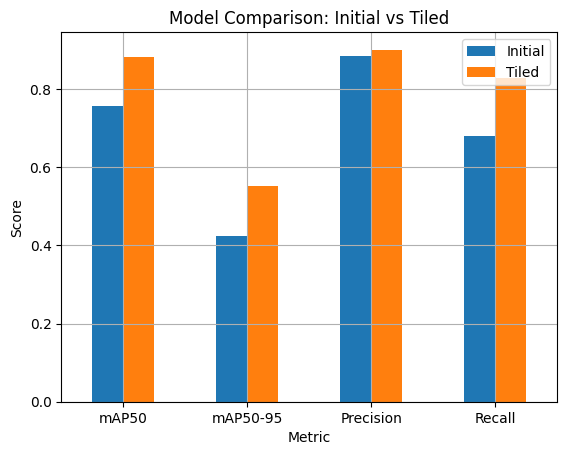

In [29]:
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(kind="bar")
plt.title("Model Comparison: Initial vs Tiled")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()

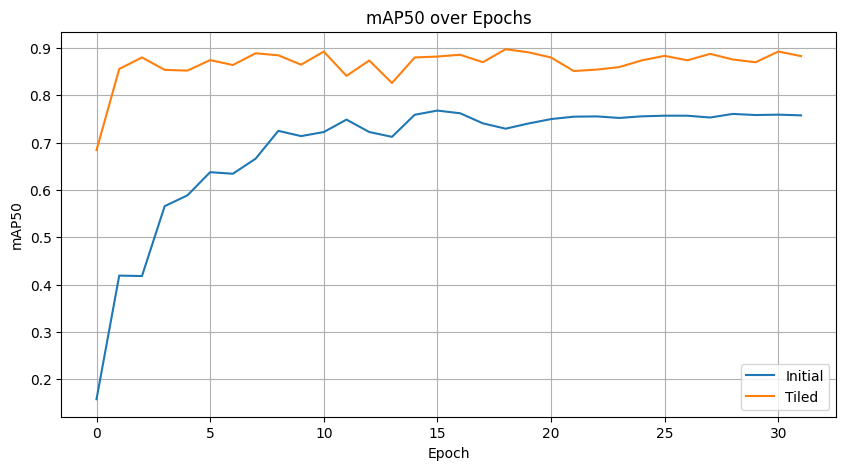

In [30]:
plt.figure(figsize=(10,5))

plt.plot(run1["metrics/mAP50(B)"], label="Initial")
plt.plot(run2["metrics/mAP50(B)"], label="Tiled")

plt.title("mAP50 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.grid()

plt.show()

## Training Dynamics Analysis

The training curves show that the tiled model consistently outperforms the baseline.

### Observations

* The tiled model achieves higher mAP50 across epochs
* Convergence is faster and more stable
* Less fluctuation in performance during training

### Interpretation

Tiling simplifies the learning problem by reducing scene complexity and increasing object visibility, allowing the model to learn more robust features.


## Final Comparison: Baseline vs Tiled Model

After applying the tiling strategy, the model shows a clear and consistent improvement over the baseline.

### Quantitative Comparison

* mAP50 improved from **0.757** → **0.883**
* mAP50-95 improved from **0.424** → **0.553**
* Precision improved from **0.886** → **0.901**
* Recall improved from **0.681** → **0.828**

### Small Object Detection

The most significant improvement is observed for the **small-vehicle** class:

* Baseline mAP50: **0.454**
* Tiled mAP50: **0.868**

This represents a major performance gain and confirms that tiling directly addresses the small object detection problem.

### Key Takeaway

Tiling increases the relative size of small objects and enhances local feature learning, leading to significantly improved detection performance in aerial imagery.


In [31]:
import shutil

shutil.make_archive(
    base_name="/content/runs_obb_backup",
    format="zip",
    root_dir="/content",
    base_dir="runs_obb"
)

print("ZIP créé ✅")

ZIP créé ✅


In [32]:
from google.colab import files

files.download("/content/runs_obb_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Deployment Consideration

Since the model was trained on tiled images, inference on full-resolution images requires applying the same tiling strategy at prediction time.

This involves:

* Splitting the input image into tiles
* Running inference on each tile
* Merging predictions back into the original image space

This step is essential to maintain performance consistency in real-world applications.


# Conclusion

This project demonstrates the importance of data-centric strategies in improving object detection performance on aerial imagery.

### Key Findings

* Oriented Bounding Box (OBB) detection is well-suited for aerial scenes with rotated objects.
* The baseline model performs well on large objects but struggles with small ones, particularly vehicles.
* Small object detection is strongly affected by scale and image resolution.

### Impact of Tiling

By applying a tiling strategy, we significantly improved model performance:

* mAP50 increased from **0.757** to **0.883**
* mAP50-95 increased from **0.424** to **0.553**
* Small-vehicle detection improved from **0.454** to **0.868**

This confirms that tiling is an effective solution for addressing scale-related limitations in high-resolution images.

### Key Takeaway

Improving data representation can be as impactful as changing the model itself.
In this case, a simple preprocessing strategy led to substantial performance gains.

### Next Steps

* Build an inference pipeline on full-resolution images using tiling + prediction merging
* Deploy the model as a FastAPI service
* Optimize inference speed and scalability
